### Problem 1: 
#### Approximate the solution to 
$$u_t(x,t) = u_{xx}(x,t) + 100tx, 0\le x \le 1, t\ge 0$$
$$ u(0,t) = u(1,t) = 0, \quad u(x,0) = 0$$

#### 1b) Solving using Forard Euler

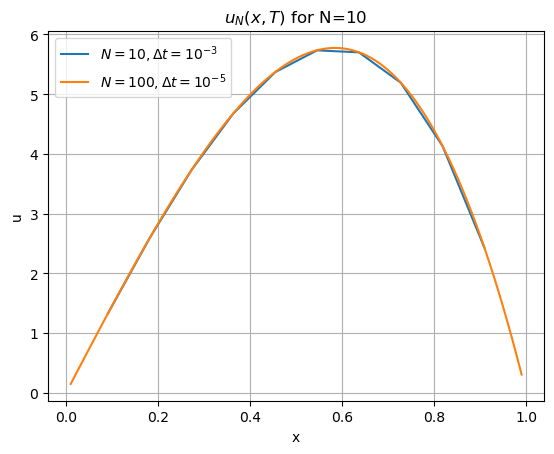

In [1]:
import numpy as np
def solve_pde_fw_euler(N,dt,T):
    """ 
    Solve the specific PDE for this problem (not a general function)

    Args:
        N: Interior nodes
        dt: timestep
        T: Final time
        M: mass matrix
        K: 
    """

    ## Grid setup
    h = 1/(N+1)
    x = np.zeros(N)
    for i in range(N):
        x[i] = (i+1)*h

    # Initial condition
    a0 = np.zeros(N)


    # Mass and stiffness matrices
    M = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            # diag
            if i == j:
                M[i,j] = 2*h/3
            # off diag
            elif np.abs(i - j) == 1:
                M[i,j] = h/6

    K = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            # diag
            if i == j:
                K[i,j] = 2/h
            # off diag
            elif np.abs(i - j) == 1:
                K[i,j] = -1/h

    # FW Euler
    num_steps = int(T/dt)
    a_coeffs = np.zeros((num_steps,N))
    a_coeffs[0] = a0

    f = np.zeros(N)
    for n in range(num_steps - 1):
        t = n*dt
        
        # Load vector
        for i in range(N):
            f[i] = 100*t*h*x[i]

        rhs = -K @ a_coeffs[n] + f
        a_prime = np.linalg.solve(M,rhs)

        an = a_coeffs[n] + dt*a_prime
        a_coeffs[n+1] = an

    # # Reconstructing u_N(x,T)
    # ux = np.zeros(N)

    # for i,xi in enumerate(x):
    #     u = 0

    #     for k in range(N):
    #         u+= a_coeffs[i]*phi_k(xi)

    return a_coeffs,x

import matplotlib.pyplot as plt
dt = 0.001
T = 1
N = 10
a_coeffs3,x3 = solve_pde_fw_euler(N,dt,T)
a_coeffs4,x4 = solve_pde_fw_euler(10*N,dt/100,T)

plt.plot(x3,a_coeffs3[-1],label=r'$N=10,\Delta t=10^{-3}$')
plt.plot(x4,a_coeffs4[-1],label=r'$N=100,\Delta t=10^{-5}$')
plt.title(r'$u_N(x,T)$ for N=10' )
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.grid()
plt.show()

#### 1c) Implicit Euler

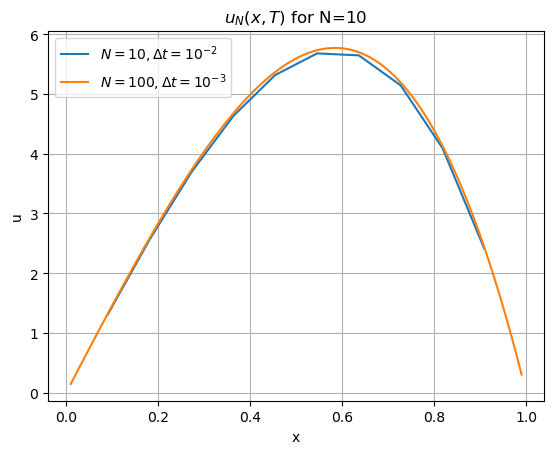

In [6]:
import numpy as np
def solve_pde_im_euler(N,dt,T):
    """ 
    Solve the specific PDE for this problem (not a general function)

    Args:
        N: Interior nodes
        dt: timestep
        T: Final time
        M: mass matrix
        K: 
    """

    ## Grid setup
    h = 1/(N+1)
    x = np.zeros(N)
    for i in range(N):
        x[i] = (i+1)*h

    # Initial condition
    a0 = np.zeros(N)


    # Mass and stiffness matrices
    M = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            # diag
            if i == j:
                M[i,j] = 2*h/3
            # off diag
            elif np.abs(i - j) == 1:
                M[i,j] = h/6

    K = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            # diag
            if i == j:
                K[i,j] = 2/h
            # off diag
            elif np.abs(i - j) == 1:
                K[i,j] = -1/h

    # Implicit Euler
    num_steps = int(T/dt)
    a_coeffs = np.zeros((num_steps,N))
    a_coeffs[0] = a0
    A = M + dt*K  


    f = np.zeros(N)
    for n in range(num_steps - 1):
        t = n*dt
        
        # Load vector
        for i in range(N):
            f[i] = 100*t*h*x[i]

        t_new = (n+1)*dt
        f_new = 100 * t_new * h * x
        rhs = M @ a_coeffs[n] + dt * f_new
        a_coeffs[n+1] = np.linalg.solve(A, rhs)


    return a_coeffs,x

import matplotlib.pyplot as plt
dt = 0.01
T = 1
N = 10
a_coeffs3,x3 = solve_pde_im_euler(N,dt,T)
a_coeffs4,x4 = solve_pde_im_euler(10*N,dt/10,T)

plt.plot(x3,a_coeffs3[-1],label=r'$N=10,\Delta t=10^{-2}$')
plt.plot(x4,a_coeffs4[-1],label=r'$N=100,\Delta t=10^{-3}$')
plt.title(r'$u_N(x,T)$ for N=10' )
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.grid()
plt.show()

### Problem 2
$$ -\nabla u = f(x,y) $$

##### d) Solving the Neumann problem

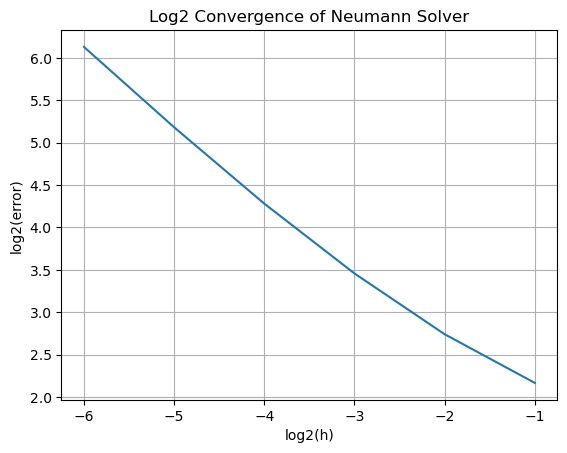

In [11]:

def solve_neumann(n,f,gl,gr,gt,gb):
    """
    Solve Neumann BVP 
    """
    h = 1/n

    def index(i,j):
        return i + j*(n+1)
    
    N = (n+1)*(n+1)

    L = np.zeros((N,N))
    b = np.zeros(N)

    # Creating L and b
    for j in range(n+1):
        y = j*h
        for i in range(n+1):
            x = i*h
            k = index(i,j)

            center_coefficient = 0

            # Left Boundary
            if i == 0:
                kp = index(i+1,j)

                L[k,kp] += -2/h**2
                center_coefficient += 2/h**2

                b[k] += (2/h) *gl(y)
            
            # Right boundart
            elif i ==n:
                km = index(i-1,j)

                L[k,km] += -2/h**2
                center_coefficient += 2/h**2

                b[k] += -(2/h)*gr(y)

            # interior w.r.t x
            else:
                km = index(i-1,j)
                kp = index(i+1,j)

                L[k,km] += -1/h**2
                L[k,kp] += -1/h**2
                center_coefficient += 2/h**2


            if j==0:
                kp = index(i,j+1)

                L[k,kp] += -2/h**2
                center_coefficient += 2/h**2

                b[k] += 2/h*gb(x)

            elif j==n:
                km = index(i,j-1)

                L[k,km] += -2/h**2
                center_coefficient += 2/h**2

                b[k] += -2/h*gt(x)

            else:
                km = index(i,j-1)
                kp = index(i,j+1)

                L[k,km] += -1/h**2
                L[k,kp] += -1/h**2
                center_coefficient += 2/h**2

            L[k,k] += center_coefficient

            b[k] += f(x,y)

    # b mean correction
    mean_b = sum(b)/N

    for k in range(N):
        b[k] -= mean_b

    # Fixing nullspace
    k0 = 0
    L[k0,:] = 0
    L[:,k0] = 0
    L[k0,k0] = 1

    b[k0] = 0

    # Solve and reshape
    u = np.linalg.solve(L,b)
    U = u.reshape((n+1, n+1))

    return U

f = lambda x,y: 20*np.sin(4*x + 2*y)
gl = lambda y: -4*np.cos(2*y)
gr = lambda y: 4*np.cos(4+2*y)
gb = lambda x: -2*np.cos(4*x)
gt = lambda x: 2*np.cos(4*x + 2)

n_list = [2,4,8,16,32,64]
h_list = [1/n for n in n_list]
errors = []
for n in n_list:

    u_calc = solve_neumann(n,f,gl,gr,gt,gb)

    # Analytical solution
    X = np.linspace(0,1,n+1)
    Y = np.linspace(0,1,n+1)

    X,Y = np.meshgrid(X,Y,indexing='ij')
    u_truth = np.sin(4*X + 2*Y)

    # correction based on inf solutions of u
    error = u_calc - u_truth
    error -= np.mean(error)

    norm = np.linalg.norm(error)
    errors.append(norm)


import matplotlib.pyplot as plt
log_h = [np.log2(h) for h in h_list]
log_e = [np.log2(e) for e in errors]
plt.plot(log_h,log_e)
plt.grid()
plt.title('Log2 Convergence of Neumann Solver')
plt.xlabel('log2(h)')
plt.ylabel('log2(error)')
plt.show()



